## Objective
Add a hidden Linear → BatchNorm → ReLU → Linear head (hidden_dim=256) on top of the
DenseNet backbone, while retaining pos_weight from experiment 02. Isolates the effect
of a deeper, batch-normalised classifier head over a direct linear one.
 
## Architecture Changes
 
| Component | 02. Baseline Weighted | 03. BatchNorm Weighted |
|---|---|---|
| Pretrained | False | False |
| Frozen backbone | False | False |
| Hidden dim | 0 | **256** |
| Head structure | Linear | **Linear → BN → ReLU → Linear** |
| Dropout | 0.0 | 0.0 |
| Pos weight | enabled | enabled |
| Optimiser | AdamW | AdamW |
| Weight decay | 1e-4 | 1e-4 |
| LR | 1e-3 | 1e-3 |
| Epochs | 30 | 30 |
 
## Hypothesis
A single linear head may be too weak to separate the 1024-dim DenseNet features.
Adding a hidden layer with batch normalisation gives the classifier more capacity
and stabilises activations, which should improve balanced accuracy and F2 compared
to experiment 02, without introducing overfitting (no dropout yet).

## Import libraries, set seed, and choose device

In [1]:
import sys
import random
from pathlib import Path
 
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
 
ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))
 
from src.data.dataset import HAM10000Dataset
from src.data.dataloader import get_dataloaders
from src.data.transform import get_augmented_train_transforms
from src.models.densenet import get_densenet121
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model
 
import pandas as pd
 
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
 
set_seed(42)
 
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


## Load and split data

In [2]:
train_dataset = HAM10000Dataset(
    csv_path=str(ROOT / 'data_new/splits/train.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    transform=get_augmented_train_transforms(image_size=224),
)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
)
 
_, val_loader, test_loader = get_dataloaders(
    train_csv=str(ROOT / 'data_new/splits/train.csv'),
    val_csv=str(ROOT / 'data_new/splits/val.csv'),
    test_csv=str(ROOT / 'data_new/splits/test.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    test_image_dir=str(ROOT / 'data_new/images/test'),
    batch_size=32,
    image_size=224,
    num_workers=4,
)
 
train_df     = pd.read_csv(ROOT / 'data_new/splits/train.csv')
num_melanoma = (train_df['label'] == 1).sum()
num_nevus    = (train_df['label'] == 0).sum()
pos_weight   = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)
print('Positive weight:', pos_weight)

Positive weight: tensor([8.1117], device='cuda:0')


## Model Definition

In [3]:
model = get_densenet121(
    num_classes=1,
    pretrained=False,
    freeze_backbone=False,
    dropout=0.0,
    hidden_dim=256,
).to(device)
 
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
 
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
 
num_epochs = 30
scheduler  = CosineAnnealingLR(optimizer, T_max=num_epochs)
 
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')
print('Pretrained: False | Frozen: False | Dropout: 0.0 | Hidden dim: 256 | Head: Linear → BN → ReLU → Linear')

Trainable params: 7,217,025 / 7,217,025
Pretrained: False | Frozen: False | Dropout: 0.0 | Hidden dim: 256 | Head: Linear → BN → ReLU → Linear


## Training Loop

In [4]:
best_val_auc = 0.0
train_history, val_history = [], []
 
for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics   = validate_one_epoch(model, val_loader, criterion, device)
 
    scheduler.step()
 
    train_history.append(train_metrics)
    val_history.append(val_metrics)
 
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train | Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f}, AUC: {train_metrics['auc']:.4f}")
    print(f"  Val   | Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}, AUC: {val_metrics['auc']:.4f}")
 
    if val_metrics['auc'] > best_val_auc:
        best_val_auc = val_metrics['auc']
        torch.save(model.state_dict(), ROOT / 'models/densenet121_batchnorm_weighted_best.pth')
        print(f'  -> Saved best model (val AUC: {best_val_auc:.4f})')

Epoch [1/30]
  Train | Loss: 1.1316, Bal Acc: 0.6305, Recall: 0.7252, F2: 0.4271, AUC: 0.6826
  Val   | Loss: 1.0454, Bal Acc: 0.6846, Recall: 0.8602, F2: 0.5012, AUC: 0.7378
  -> Saved best model (val AUC: 0.7378)


Epoch [2/30]
  Train | Loss: 1.0664, Bal Acc: 0.6724, Recall: 0.7583, F2: 0.4674, AUC: 0.7362
  Val   | Loss: 1.1621, Bal Acc: 0.6737, Recall: 0.8178, F2: 0.4879, AUC: 0.7278


Epoch [3/30]
  Train | Loss: 1.0102, Bal Acc: 0.7024, Recall: 0.7799, F2: 0.4985, AUC: 0.7681
  Val   | Loss: 0.9703, Bal Acc: 0.7095, Recall: 0.9576, F2: 0.5298, AUC: 0.7898
  -> Saved best model (val AUC: 0.7898)


Epoch [4/30]
  Train | Loss: 0.9761, Bal Acc: 0.7103, Recall: 0.7799, F2: 0.5068, AUC: 0.7854
  Val   | Loss: 0.8826, Bal Acc: 0.7634, Recall: 0.8898, F2: 0.5824, AUC: 0.8315
  -> Saved best model (val AUC: 0.8315)


Epoch [5/30]
  Train | Loss: 0.9386, Bal Acc: 0.7362, Recall: 0.8198, F2: 0.5366, AUC: 0.8038
  Val   | Loss: 0.9495, Bal Acc: 0.7114, Recall: 0.9619, F2: 0.5316, AUC: 0.8121


...

Epoch [26/30]
  Train | Loss: 0.8114, Bal Acc: 0.7754, Recall: 0.8461, F2: 0.5842, AUC: 0.8589
  Val   | Loss: 0.8489, Bal Acc: 0.7624, Recall: 0.8983, F2: 0.5811, AUC: 0.8529


Epoch [27/30]
  Train | Loss: 0.8008, Bal Acc: 0.7768, Recall: 0.8461, F2: 0.5860, AUC: 0.8598
  Val   | Loss: 0.8508, Bal Acc: 0.7620, Recall: 0.9025, F2: 0.5807, AUC: 0.8525


Epoch [28/30]
  Train | Loss: 0.8104, Bal Acc: 0.7710, Recall: 0.8461, F2: 0.5785, AUC: 0.8570
  Val   | Loss: 0.8617, Bal Acc: 0.7600, Recall: 0.9110, F2: 0.5786, AUC: 0.8504


Epoch [29/30]
  Train | Loss: 0.7903, Bal Acc: 0.7836, Recall: 0.8666, F2: 0.5939, AUC: 0.8640
  Val   | Loss: 0.8487, Bal Acc: 0.7567, Recall: 0.8898, F2: 0.5747, AUC: 0.8523


Epoch [30/30]
  Train | Loss: 0.8078, Bal Acc: 0.7814, Recall: 0.8597, F2: 0.5914, AUC: 0.8615
  Val   | Loss: 0.8481, Bal Acc: 0.7610, Recall: 0.8856, F2: 0.5796, AUC: 0.8517


## Plot Train and Validation Curves

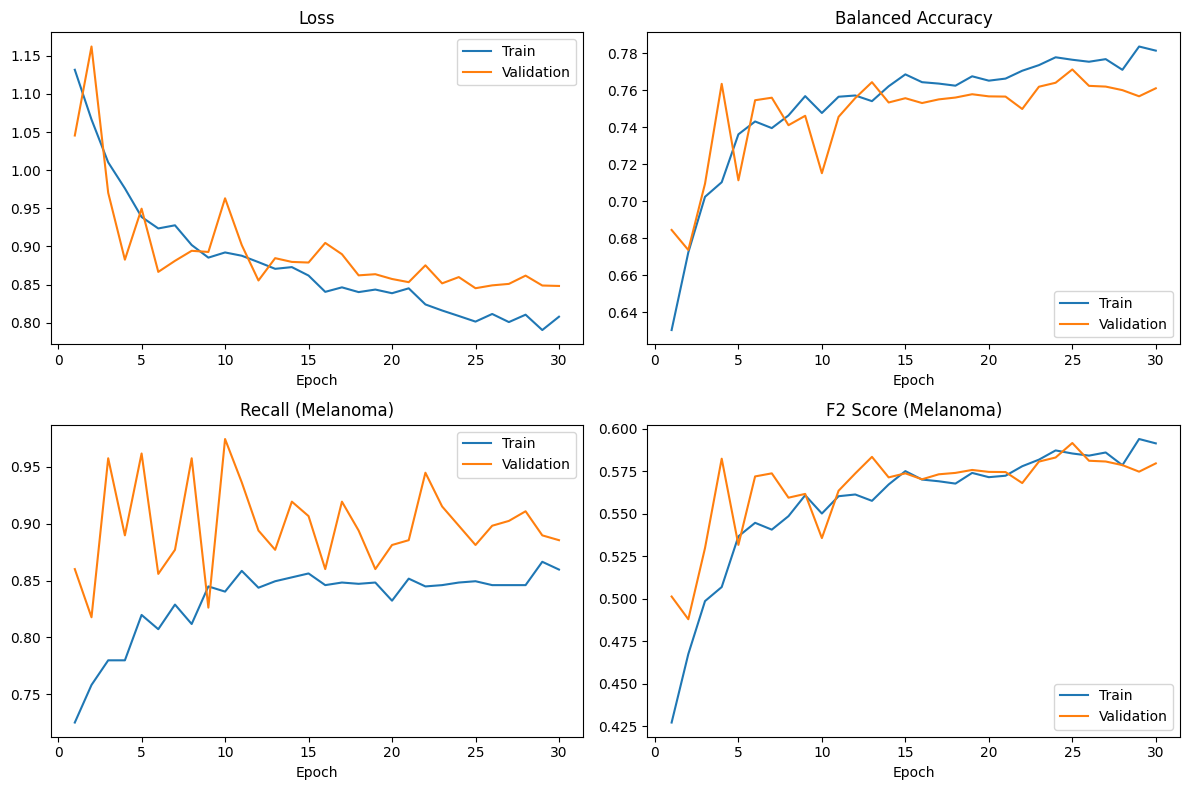

In [5]:
plot_training_curves(train_history, val_history)

## Threshold Tuning (Best Val F2)

In [6]:
model.load_state_dict(torch.load(str(ROOT / 'models/densenet121_batchnorm_weighted_best.pth'), map_location=device))
best_threshold, best_f2 = find_best_threshold(model, val_loader, device)

C:\Users\1008462\AppData\Local\Temp\ipykernel_38108\2719648782.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(str(ROOT / 'models/densen

Best threshold: 0.63 | Val F2: 0.5978


## Test Set Evaluation

Threshold:          0.63
AUC-ROC:            0.8580
Balanced Accuracy:  0.7791
F2 Score:           0.5964

              precision    recall  f1-score   support

Non-Melanoma     0.9704    0.7336    0.8355      1340
    Melanoma     0.2831    0.8246    0.4215       171

    accuracy                         0.7439      1511
   macro avg     0.6268    0.7791    0.6285      1511
weighted avg     0.8926    0.7439    0.7887      1511



C:\Users\1008462\Desktop\50.021_project_group4\venv\Lib\site-packages\sklearn\utils\_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


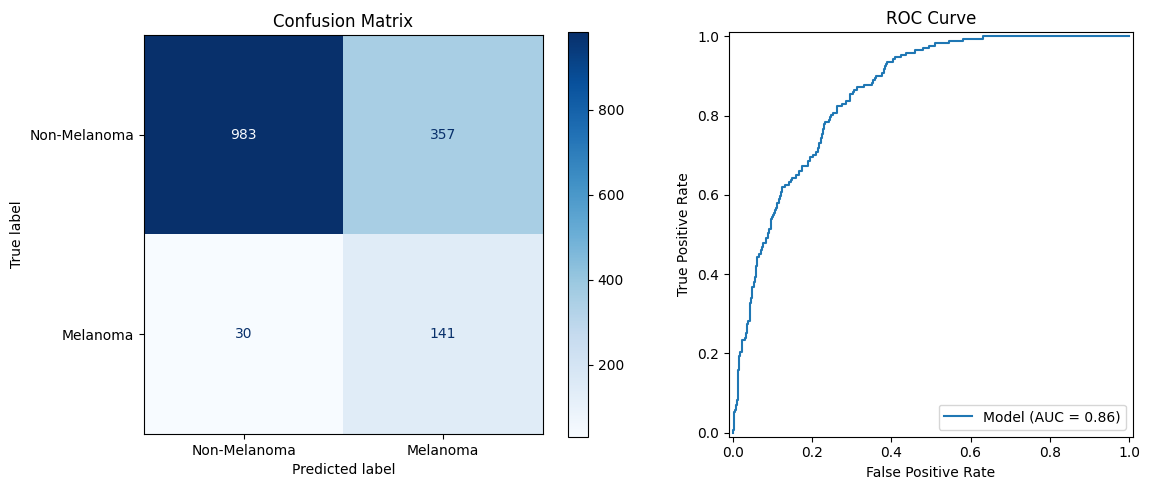

In [7]:
evaluate_model(model, test_loader, device, threshold=best_threshold)